In [1]:
import uproot 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import colors
import math as math
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve

In [2]:
data24 = pd.read_pickle('data24_magdown_50_all.pkl')
mc_data = pd.read_pickle('mc_data_all.pkl')

Aqui hay que añadir las nuevas variables del DOCA y IP 

In [3]:
training_keys = ['Jpsi_PT','Jpsi_MAXDOCA', 'Jpsi_BPVDIRA', 'Jpsi_ETA', 
            'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2', 'L_PT','L_P', 'L_CHI2','L_END_VZ','L_END_VX', 'L_END_VY', 'L_MASS',
            'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT','Lb_CHI2','Lb_MINIPCHI2',  'Lb_ETA', 
            'p_PID_P', 'p_MINIP', 'p_P', 'p_PT', 'p_ETA','p_GHOSTPROB',
            'mup_PID_MU',
            'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB'] +['SUMCHI2','Cos_xi_LbP','Cos_xi_LP','xi_LbP', 'xi_LP']

In [4]:
data24

,L_MASS,Lb_MASS,Jpsi_MASS,Jpsi_P,Jpsi_PT,Jpsi_ETA,Jpsi_CHI2,Jpsi_MAXDOCA,Jpsi_BPVDIRA,Jpsi_END_VRHO,...,pim_PZ_V,pim_X_V,pim_Y_V,p_TX,p_TY,pim_TX,pim_TY,DOCA,p_RK_IP,pim_RK_IP
0,1077.975830,5846.956055,2974.502686,54863.386719,1776.397949,4.123077,0.005935,0.002314,0.997817,1.207904,...,11680.919315,-10.835969,75.261326,-0.013627,0.018673,0.018514,0.019425,0.210603,49.721427,310.922226
1,1077.976562,5313.719238,3112.583496,58726.832031,1343.211792,4.470844,0.122067,0.009861,0.997888,1.222700,...,8786.270291,-147.728206,-50.450625,-0.016325,-0.013974,-0.058505,-0.013156,1.886890,77.313709,415.410681
2,1078.187256,6402.193359,3093.716309,18753.294922,2738.893555,2.611505,0.071255,0.009010,0.984698,1.317595,...,4819.569861,205.566897,-218.430465,-0.028050,-0.036172,0.252932,-0.036954,8.133840,30.332094,14.064989
3,1078.331421,5060.589355,3078.505615,36252.464844,492.338257,4.992107,1.107087,0.028151,0.996496,1.103896,...,7953.262103,-172.944417,-2.058991,-0.016683,0.003845,-0.030802,0.002457,0.484488,98.566212,649.269899
4,1078.344971,5300.834473,2953.872803,26179.085938,1636.410034,3.464616,1.147581,0.034740,0.992858,1.206773,...,16774.833827,-170.274727,-72.234454,-0.022561,-0.008554,-0.023594,-0.008810,0.028781,52.032315,348.617818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3171843,1699.998535,5481.383789,3063.761230,65743.992188,1356.536865,4.573864,1.885007,0.041434,0.998666,1.301863,...,2459.657136,278.724574,375.612638,0.017463,0.046223,0.217304,0.065413,7.829135,88.920897,1093.558259
3171844,1699.998535,5328.483398,3022.227539,113000.929688,2035.559937,4.709600,0.013086,0.005731,0.999940,1.240183,...,29762.213420,-105.980358,-52.638200,-0.011106,-0.019972,-0.059777,-0.022595,28.573664,335.902751,364.482089
3171845,1699.998535,5363.164551,3069.586182,113130.843750,2043.669678,4.706774,0.005535,0.003733,0.999941,1.240008,...,29762.213420,-105.980358,-52.638200,-0.011106,-0.019972,-0.059777,-0.022595,28.573664,335.902751,364.482089
3171846,1699.999146,5104.324707,3084.939697,32234.619141,2095.427002,3.425304,1.892915,0.034274,0.999294,0.993032,...,5262.849624,31.525269,-186.931477,-0.035805,-0.037094,0.183826,-0.050636,18.277817,64.724714,147.996554


In [5]:
mc_data

,L_MASS,Lb_MASS,Jpsi_MASS,Jpsi_P,Jpsi_PT,Jpsi_CHI2,Jpsi_MAXDOCA,Jpsi_BPVDIRA,Jpsi_END_VRHO,Jpsi_END_VX,...,pim_PZ_V,pim_X_V,pim_Y_V,p_TX,p_TY,pim_TX,pim_TY,DOCA,p_RK_IP,pim_RK_IP
0,1078.216064,5238.732910,3095.558350,48452.062500,915.653381,0.299717,0.015202,0.999958,1.093754,0.9605,...,6347.434049,603.633899,-87.888160,0.028349,-0.024032,-0.178990,-0.023108,2.927469,239.297461,1801.400882
1,1078.259033,5257.361816,3014.794678,145656.640625,6167.957520,0.607561,0.013176,0.999846,1.118636,1.0240,...,8304.830917,-799.335376,-75.248127,-0.061371,-0.024246,0.075773,-0.023438,1.391669,170.461951,1365.530276
3,1078.478394,5378.423828,3104.240234,107524.718750,6373.708984,0.386113,0.031794,0.999907,1.743110,1.5966,...,15895.866282,-62.495240,-179.672997,0.007876,-0.042783,0.016770,-0.043573,0.479241,59.616227,426.785828
4,1078.545044,5452.856934,3114.653809,75249.507812,12491.000000,2.606676,0.030760,0.998852,1.256283,1.1800,...,4499.429765,460.188046,-250.966940,0.097050,-0.044477,0.066274,-0.039301,1.964708,142.260138,1106.174407
6,1078.846558,5150.160645,3109.953369,58382.671875,2565.219727,1.778421,0.030807,0.999737,1.657983,1.5057,...,5194.596327,551.206529,185.567668,0.084514,0.028904,0.097336,0.026315,1.887912,193.641135,1220.761827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99815,1699.889526,6187.048340,3113.975098,182840.265625,4920.676758,2.760785,0.033684,0.999967,1.260225,1.1663,...,10759.950513,-4.171114,-92.148110,0.052126,-0.023856,-0.094271,-0.046223,35.922793,11.415949,101.780203
99817,1699.902954,5329.004395,3107.208496,34801.566406,862.707825,2.338604,0.085805,0.999984,0.992543,0.9334,...,4704.339540,471.586803,114.132867,0.009876,0.030760,-0.133941,0.043626,41.971310,378.586019,1939.684836
99821,1699.963257,5403.758301,3102.406738,30079.544922,1179.017822,0.439143,0.017408,0.999255,1.220537,1.1252,...,7392.959119,-514.084603,326.225829,0.000743,0.109228,0.056674,0.109514,45.956974,494.397834,1181.618783
99822,1699.978271,6048.416992,3103.485107,179971.515625,9405.648438,1.092537,0.014153,0.999942,1.145118,1.0980,...,6395.929357,2.757377,-86.124568,0.061690,-0.018446,-0.152039,-0.002582,63.131394,7.296131,120.916184


In [6]:
to_drop1 = [x for x in mc_data.columns if x not in training_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ']+ ['Lb_MASS']+ ['L_MASS']+ ['MAGFIELD']]
to_drop2 = [x for x in data24.columns if x not in training_keys + ['Lb_MASS']+ ['L_MASS']]

In [7]:
print(to_drop1)
print(to_drop2)

['Jpsi_MASS', 'Jpsi_P', 'Jpsi_CHI2', 'Jpsi_END_VRHO', 'Jpsi_END_VX', 'Jpsi_END_VY', 'Jpsi_END_VZ', 'Jpsi_BPVIP', 'Jpsi_MINIPCHI2', 'L_PX', 'L_PY', 'L_PZ', 'L_BPVFDCHI2', 'L_MINIPCHI2', 'Lb_PX', 'Lb_PY', 'Lb_PZ', 'Lb_BPVIPCHI2', 'Lb_BPVFDCHI2', 'p_PX', 'p_PY', 'p_PZ', 'p_PID_K', 'pim_PX', 'pim_PY', 'pim_PZ', 'mum_P', 'mum_PT', 'mum_PX', 'mum_PY', 'mum_PZ', 'mum_CHI2', 'mum_GHOSTPROB', 'mum_PID_P', 'mum_PID_K', 'mum_PID_MU', 'mum_PID_E', 'mum_MINIP', 'mum_MINIPCHI2', 'mup_P', 'mup_PT', 'mup_PX', 'mup_PY', 'mup_PZ', 'mup_CHI2', 'mup_GHOSTPROB', 'mup_PID_P', 'mup_PID_K', 'mup_PID_E', 'mup_MINIP', 'mup_MINIPCHI2', 'totCandidates', 'p_QOVERP', 'pim_QOVERP', 'Lb_END_VX', 'Lb_END_VY', 'Lb_END_VZ', 'L_TRUEP', 'L_TRUEPX', 'L_TRUEPY', 'L_TRUEPZ', 'p_TRUEP', 'p_TRUEPX', 'p_TRUEPY', 'p_TRUEPZ', 'pim_TRUEP', 'pim_TRUEPX', 'pim_TRUEPY', 'pim_TRUEPZ', 'L_TRUEID', 'pim_TRUEID', 'p_TRUEID', 'p_TRUEENERGY', 'pim_TRUEENERGY', 'L_TRUEENERGY', 'p_MC_GD_MOTHER_ID', 'p_MC_MOTHER_ID', 'pim_MC_GD_MOTHER_ID', 'p

In [8]:
mc_data.drop(columns=to_drop1, inplace=True)
data24.drop(columns=to_drop2, inplace=True)

In [9]:
mc_data

,L_MASS,Lb_MASS,Jpsi_PT,Jpsi_MAXDOCA,Jpsi_BPVDIRA,L_P,L_PT,L_CHI2,L_END_VZ,L_END_VX,...,Jpsi_ETA,pim_ETA,Lb_ETA,p_ETA,MAGFIELD,Cos_xi_LbP,Cos_xi_LP,xi_LP,xi_LbP,SUMCHI2
0,1078.216064,5238.732910,915.653381,0.015202,0.999958,49633.324219,1198.487549,0.493996,3596.858398,33.169800,...,4.661691,2.413357,5.346755,3.985816,True,0.999350,0.999636,0.026965,0.036062,1.753419
1,1078.259033,5257.361816,6167.957520,0.013176,0.999846,62256.269531,3053.132568,0.011475,2773.745361,-158.011307,...,3.854582,3.229007,3.802217,3.412443,True,0.999684,0.999827,0.018593,0.025122,4.277021
3,1078.478394,5378.423828,6373.708984,0.031794,0.999907,131119.828125,5756.950195,0.187007,4225.615723,41.167599,...,3.517729,3.757939,3.680520,3.828580,True,0.999912,0.999999,0.001145,0.013256,1.265592
4,1078.545044,5452.856934,12491.000000,0.030760,0.998852,34788.062500,3542.150635,8.100865,5421.818848,510.521606,...,2.481976,3.257868,2.618530,2.933115,False,0.999183,0.999990,0.004367,0.040418,22.678582
6,1078.846558,5150.160645,2565.219727,0.030807,0.999737,41821.460938,3772.997070,3.357353,6646.442383,581.727112,...,3.817639,2.989943,3.465483,3.110670,False,0.999598,0.999997,0.002367,0.028365,5.225974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99815,1699.889526,6187.048340,4920.676758,0.033684,0.999967,42685.945312,1386.490356,13.284162,3964.677734,18.396299,...,4.308047,2.949673,4.436657,3.552875,False,0.999413,0.999115,0.042082,0.034261,42.498470
99817,1699.902954,5329.004395,862.707825,0.085805,0.999984,29330.285156,1015.178101,4.434874,4249.526367,-17.361300,...,4.390291,2.657919,4.998681,4.125830,True,0.999426,0.999711,0.024026,0.033889,26.898869
99821,1699.963257,5403.758301,1179.017822,0.017408,0.999255,27959.101562,3078.697998,0.042863,3206.360352,86.714798,...,3.931894,2.789949,3.461880,2.910316,True,0.998213,0.999883,0.015286,0.059787,35.575795
99822,1699.978271,6048.416992,9405.648438,0.014153,0.999942,37435.421875,1063.633667,9.623646,3555.705811,49.225800,...,3.643880,2.582295,3.749182,3.436945,False,0.997711,0.999290,0.037690,0.067674,31.017563


In [10]:
data24

,L_MASS,Lb_MASS,Jpsi_PT,Jpsi_ETA,Jpsi_MAXDOCA,Jpsi_BPVDIRA,L_P,L_PT,L_CHI2,L_END_VZ,...,pim_P,pim_ETA,pim_PT,pim_GHOSTPROB,mup_PID_MU,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP,SUMCHI2
0,1077.975830,5846.956055,1776.397949,4.123077,0.002314,0.997817,88352.117188,1860.207520,0.103174,4249.742188,...,11699.349609,4.311304,313.833801,0.162915,7.493675,0.999991,0.999902,0.004257,0.014029,1.332619
1,1077.976562,5313.719238,1343.211792,4.470844,0.009861,0.997888,68503.218750,1763.939941,0.112574,3882.144775,...,8797.104492,3.507957,526.579773,0.113319,0.347026,0.999985,0.999979,0.005426,0.006496,1.834390
2,1078.187256,6402.193359,2738.893555,2.611505,0.009010,0.984698,36373.828125,1361.485962,0.012034,5504.375977,...,4879.762695,2.073149,1208.495483,0.020753,12.058558,0.999327,0.999409,0.036701,0.034373,8.643069
3,1078.331421,5060.589355,492.338257,4.992107,0.028151,0.996496,56604.093750,1075.201782,0.629229,4587.109863,...,7967.841309,4.170358,246.089371,0.277531,6.811736,0.999998,0.999966,0.002072,0.008250,24.885163
4,1078.344971,5300.834473,1636.410034,3.464616,0.034740,0.992858,127491.195312,3093.562744,0.001181,7442.494141,...,16779.119141,4.374762,422.451080,0.675442,8.349495,1.000000,0.999871,0.000000,0.016058,5.839044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3171843,1699.998535,5481.383789,1356.536865,4.573864,0.041434,0.998666,36091.449219,1945.027832,23.219116,7282.461914,...,2509.772705,2.188776,555.434082,0.632257,3.353277,0.999908,0.999131,0.013567,0.041682,56.004918
3171844,1699.998535,5328.483398,2035.559937,4.709600,0.005731,0.999940,49281.320312,2024.946411,56.315197,4906.027344,...,29867.169922,3.444481,1904.776245,0.346232,1.909957,0.999682,0.999649,0.025236,0.026490,90.689325
3171845,1699.998535,5363.164551,2043.669678,4.706774,0.003733,0.999941,49281.320312,2024.946411,56.315197,4906.027344,...,29867.169922,3.444481,1904.776245,0.346232,1.909957,0.999682,0.999649,0.025236,0.026488,90.677596
3171846,1699.999146,5104.324707,2095.427002,3.425304,0.034274,0.999294,25580.609375,1106.434814,5.147719,4923.417969,...,5279.633789,2.359294,988.867676,0.372198,2.916568,0.998954,0.999546,0.045752,0.030123,17.154321


In [11]:
training_data = mc_data[mc_data['MAGFIELD'] == False].copy() # True for MagUP and False for MagDown
training_data['SIGNAL'] = False
mask = (training_data['Lb_BKGCAT'] == 0) & (training_data['p_TRUEORIGIN_VZ'] > 2500) & (training_data['L_MASS'] < 1300) 
training_data.loc[mask,'CLASS'] = 0 #SIGNAL
training_data.loc[mask,'SIGNAL'] = True

In [12]:
print(len(training_data.query('(SIGNAL)')['SIGNAL']))

12291


In [13]:
new_training = pd.DataFrame(columns=training_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] )
new_training = new_training.merge(training_data.query('(CLASS == 0) '),how='outer')
# new_training = new_training.merge(data24_selected,how='outer')
new_training = new_training.merge(data24.query('(L_MASS > 1300) & (L_MASS < 1700) '),how='outer')

# new_training = new_training.merge(data24_selected.query('(Lb_MASS > 6200) '),how='outer')
new_training['SIGNAL'] = new_training['SIGNAL'].fillna(False)

/tmp/javeser/ipykernel_27072/1055856324.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_training['SIGNAL'] = new_training['SIGNAL'].fillna(False)


In [14]:
print(len(new_training.query('(CLASS ==0) ')['CLASS']))
print(len(new_training.query('(CLASS !=0) ')['CLASS']))

12291
1938419


In [15]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve

In [16]:
to_drop = ["SIGNAL", "Lb_BKGCAT", "p_TRUEORIGIN_VZ", 'CLASS','Lb_MASS','Cos_xi_LbP','Cos_xi_LP', 'L_MASS', 'MAGFIELD'] #, ,'xi_L', 'xi_Lb'
# to_drop = ["SIGNAL", "Lb_BKGCAT", "p_TRUEORIGIN_VZ", 'CLASS','Lb_MASS','xi_LbP', 'xi_LP'] #, 'Cos_xi_LbP','Cos_xi_LP'

In [17]:
X_tr, X_eval = train_test_split(new_training)
y_tr = X_tr.SIGNAL
y_tr_clean = y_tr == True
X_tr_copy = X_tr.copy()
X_tr.drop(columns=to_drop, inplace=True)

y_eval =  X_eval.SIGNAL
y_eval_clean = y_eval == True
X_eval_copy = X_eval.copy()
X_eval.drop(columns=to_drop, inplace=True)

In [18]:
model_params = {
    'iterations': 1000, 
    'loss_function': 'Logloss',
    'train_dir': 'crossentropy',
    'allow_writing_files': False,
    'od_type': 'IncToDec',
    'auto_class_weights' : 'Balanced',
    'random_seed' : 69
}

In [19]:
train_dataset = Pool(X_tr, y_tr_clean, feature_names=list(X_tr.columns))
eval_dataset = Pool(X_eval, y_eval_clean, feature_names=list(X_eval.columns))

In [20]:
model = CatBoostClassifier(**model_params,custom_metric=['Logloss',
                   'AUC:hints=skip_train~false','Accuracy'])
model.fit(train_dataset, verbose=True, plot=False)

Learning rate set to 0.231471
0:	learn: 0.3566605	total: 224ms	remaining: 3m 43s
1:	learn: 0.2161691	total: 362ms	remaining: 3m
2:	learn: 0.1660711	total: 519ms	remaining: 2m 52s
3:	learn: 0.1337679	total: 657ms	remaining: 2m 43s
4:	learn: 0.1148412	total: 808ms	remaining: 2m 40s
5:	learn: 0.1026678	total: 947ms	remaining: 2m 36s
6:	learn: 0.0954488	total: 1.09s	remaining: 2m 34s
7:	learn: 0.0872997	total: 1.23s	remaining: 2m 32s
8:	learn: 0.0829687	total: 1.37s	remaining: 2m 30s
9:	learn: 0.0794408	total: 1.51s	remaining: 2m 29s
10:	learn: 0.0763590	total: 1.64s	remaining: 2m 27s
11:	learn: 0.0725761	total: 1.79s	remaining: 2m 27s
12:	learn: 0.0696791	total: 1.93s	remaining: 2m 26s
13:	learn: 0.0667255	total: 2.07s	remaining: 2m 25s
14:	learn: 0.0646767	total: 2.2s	remaining: 2m 24s
15:	learn: 0.0629089	total: 2.33s	remaining: 2m 23s
16:	learn: 0.0618074	total: 2.48s	remaining: 2m 23s
17:	learn: 0.0604864	total: 2.61s	remaining: 2m 22s
18:	learn: 0.0586629	total: 2.75s	remaining: 2m 2

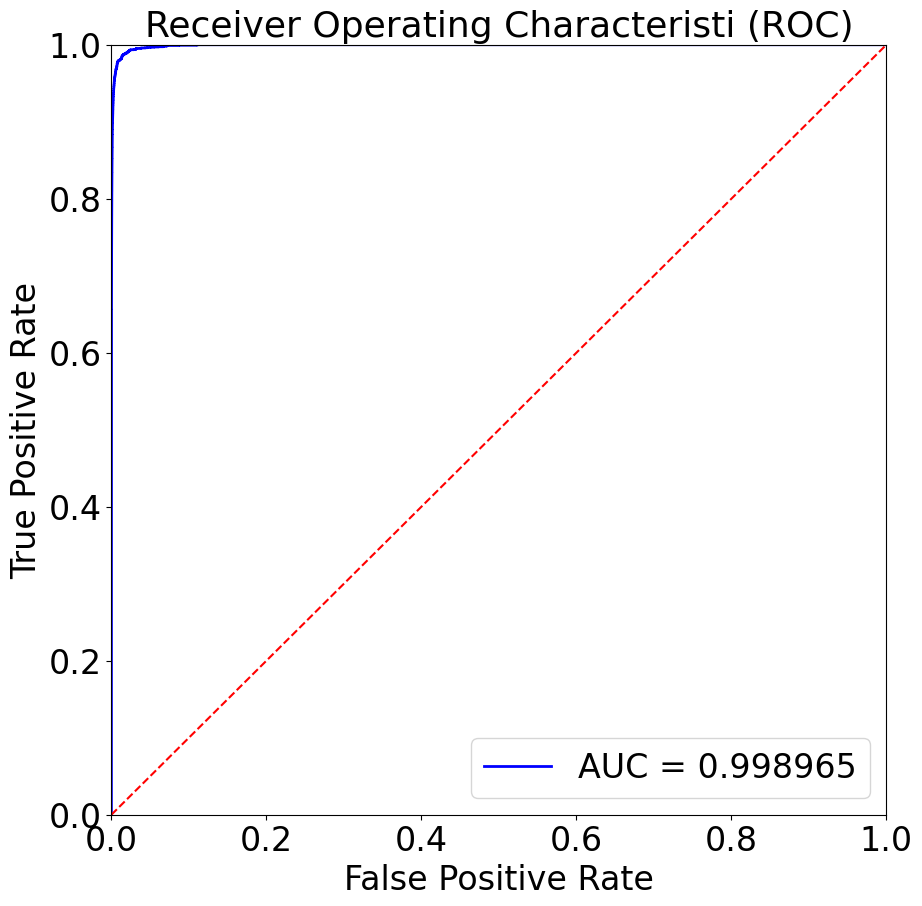

In [21]:
import sklearn.metrics as metrics
probs = model.predict_proba(X_eval)
preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_eval, preds)
roc_auc = metrics.auc(fpr, tpr)

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10,10)
plt.title('Receiver Operating Characteristi (ROC)', fontsize=26)
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.6f' % roc_auc, linewidth=2)
plt.legend(loc = 'lower right', fontsize=24)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize=24)
plt.xlabel('False Positive Rate', fontsize=24)
plt.xticks(fontsize=24) 
plt.yticks(fontsize=24) 
plt.show()

In [22]:
print(model.get_best_score())
print(model.get_all_params())

{'learn': {'Accuracy:use_weights=true': 0.9981531566548029, 'Logloss:use_weights=false': 0.010511420696418538, 'Logloss:use_weights=true': 0.007849187797250433, 'Logloss': 0.007849187797250433, 'Accuracy:use_weights=false': 0.9963295402971364, 'AUC': 0.9998660320808552}}
{'nan_mode': 'Min', 'eval_metric': 'Logloss', 'iterations': 1000, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'od_pval': 0, 'random_score_type': 'NormalWithModelSizeDecrease', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.10000000149011612, 'eval_fraction': 0, 'force_unit_auto_pair_weights': False, 'l2_leaf_reg': 3, 'random_strength': 1, 'od_type': 'IncToDec', 'rsm': 1, 'boost_from_average': False, 'model_size_reg': 0.5, 'pool_metainfo_options': {'tags': {}}, 'subsample': 0.800000011920929, 'use_best_model': False, 'od_wait': 20, 'class_names': [False, True], 

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36],
 [Text(0, 0, 'L_END_VX'),
  Text(0, 1, 'L_END_VY'),
  Text(0, 2, 'Jpsi_PT'),
  Text(0, 3, 'Jpsi_ETA'),
  Text(0, 4, 'L_BPVDIRA'),
  Text(0, 5, 'xi_LbP'),
  Text(0, 6, 'Lb_P'),
  Text(0, 7, 'Lb_MAXDOCA'),
  Text(0, 8, 'L_BPVIPCHI2'),
  Text(0, 9, 'pim_ETA'),
  Text(0, 10, 'L_CHI2'),
  Text(0, 11, 'p_ETA'),
  Text(0, 12, 'Lb_PT'),
  Text(0, 13, 'L_BPVIP'),
  Text(0, 14, 'Lb_ETA'),
  Text(0, 15, 'p_PID_P'),
  Text(0, 16, 'Jpsi_MAXDOCA'),
  Text(0, 17, 'mup_PID_MU'),
  Text(0, 18, 'p_PT'),
  Text(0, 19, 'Lb_CHI2'),
  Text(0, 20, 'p_P'),
  Text(0, 21, 'pim_PT'),
  Text(0, 22, 'Lb_BPVVDRHO'),
  Text(0, 23, 'Jpsi_BPVDIRA'),
  Text(0, 24, 'L_PT'),
  Text(0, 25, 'L_END_VRHO'),
  Text(0, 26, 'L_P'),
  Text(0, 27, 'Lb_MINIPCHI2'),
  Text(0, 28, 'L_END_VZ'),
  Text(0, 29, 'Lb_BPVIP'),
  T

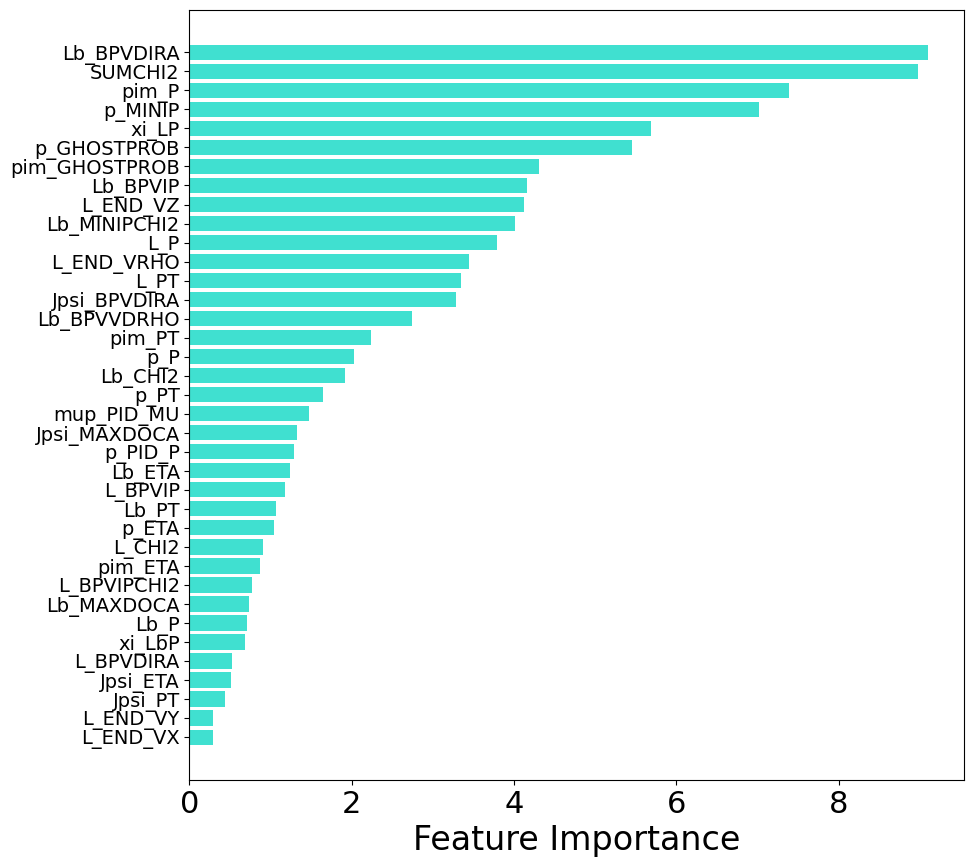

In [23]:
sorted_feature_importance = model.feature_importances_.argsort()
plt.rcParams["figure.figsize"] = (10,10)
plt.barh(X_eval.columns[sorted_feature_importance], 
        model.feature_importances_[sorted_feature_importance], 
        color='turquoise')
plt.xlabel("Feature Importance", fontsize=24)  # Ajusta el tamaño de fuente de las etiquetas en el eje y
# plt.title("Feature Importance", fontsize=24)
plt.xticks(fontsize=22)  # Ajusta el tamaño de fuente de las marcas en el eje x
plt.yticks(fontsize=14)  # Ajusta el tamaño de fuente de las etiquetas en el eje y

In [24]:
signal_MVA_prob_eval = model.predict_proba(X_eval_copy)
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
X_eval_copy['signal_MVA'] = signal_MVA_probs

signal_MVA_prob_tr = model.predict_proba(X_tr_copy)
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_tr]
X_tr_copy['signal_MVA'] = signal_MVA_probs

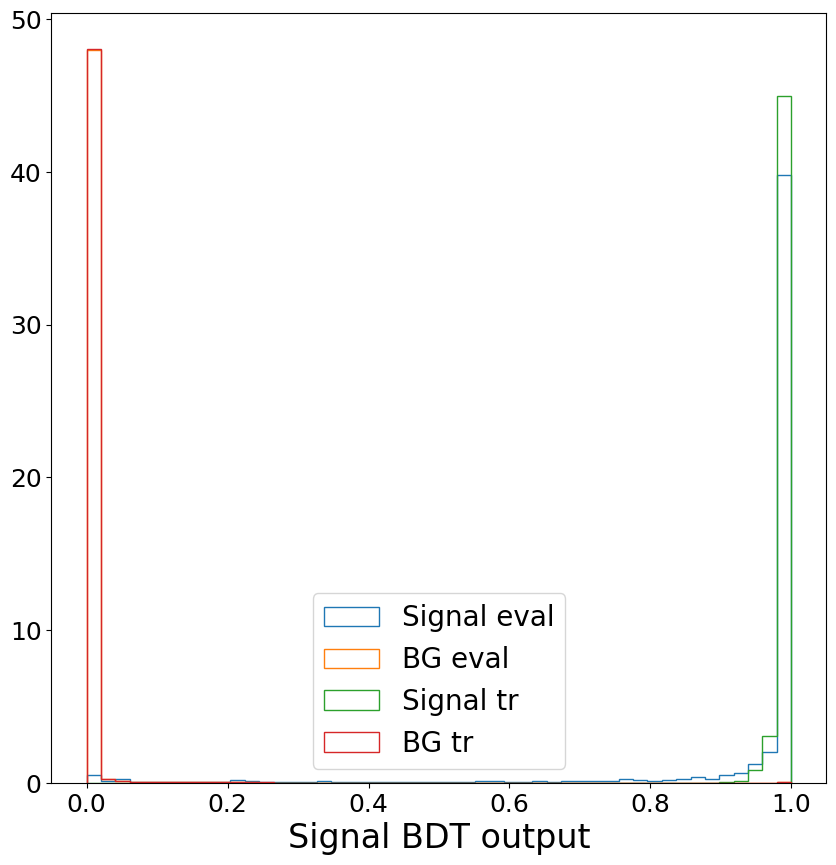

In [25]:
fig, ax = plt.subplots()

density = True

variable = 'signal_MVA'

bins = np.linspace(0,1,50)

n_sig,bins_sig, _ = ax.hist(X_eval_copy.query(f'SIGNAL')[variable], bins=bins, linewidth=1 ,label="Signal eval",histtype='step',density=density)
n_bg,bins_bg, _ = ax.hist(X_eval_copy.query(f'not SIGNAL')[variable], bins=bins, linewidth=1 ,label="BG eval",histtype='step',density=density)

ax.hist(X_tr_copy.query(f'SIGNAL')[variable], bins=bins, linewidth=1 ,label="Signal tr",histtype='step',density=density)
ax.hist(X_tr_copy.query(f'not SIGNAL')[variable], bins=bins, linewidth=1 ,label="BG tr",histtype='step',density=density)

ax.legend(fontsize=20)  # Ajusta el tamaño de fuente de la leyenda
ax.set_xlabel("Signal BDT output", fontsize=24)  # Ajusta el tamaño de fuente del eje x
plt.rcParams["figure.figsize"] = (15,10)
# Ajusta el tamaño de fuente de las marcas en los ejes x e y
# ax.tick_params(axis='both', which='major', labelsize=18)
plt.xticks(fontsize=18)  # Ajusta el tamaño de fuente de las marcas en el eje x
plt.yticks(fontsize=18)  # Ajusta el tamaño de fuente de las etiquetas en el eje y

plt.show()

Guarda el modelo para ser utilizado posteriormente

In [26]:
model.save_model('BDT_MagDown_NO_DOCA',
           format="cbm",
           export_parameters=None,
           pool=None)

In [27]:
for SIGNAL in [True, False]:
    print(f'SIGNAL == {SIGNAL}', len(new_training.query(f'(SIGNAL == {SIGNAL})')))

SIGNAL == True 12291
SIGNAL == False 1938419
